In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("ws8.ipynb")

In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
#below line allows matplotlib plots to appear in cell output
%matplotlib inline

## **Question 1**: Determining the Order of a Matrix

In this question, you'll implement a function to determine the **order** of a square matrix. The order of a matrix is the smallest positive integer $n$ such that $A^n = I$, where $I$ is the identity matrix.

### Background: Matrix Order Theory

For a square matrix $A$, the **order** (also called the **period**) is defined as the smallest positive integer $n$ such that:

$$A^n = I$$

where $I$ is the identity matrix of the same size as $A$.

**Key Concepts:**

- If $A^n = I$ for some positive integer $n$, then $A$ is called a **periodic matrix** of order $n$
- Not all matrices have a finite order (some matrices never return to the identity)
- Rotation matrices often have finite orders. For example, a 90° rotation in 2D has order 4, since rotating four times returns to the original orientation
- Permutation matrices and certain orthogonal matrices commonly have finite orders

**Mathematical Properties:**

1. **Matrix Power**: The $n$-th power of matrix $A$ is computed by multiplying $A$ by itself $n$ times:
   $$A^n = \underbrace{A \cdot A \cdot ... \cdot A}_{n \text{ times}}$$

2. **Identity Matrix**: The identity matrix $I$ is a square matrix with 1's on the diagonal and 0's elsewhere:
   $$I = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix} \quad \text{(for 3×3)}$$

3. **Matrix Equality with Tolerance**: Due to numerical precision limitations in computers, we check if two matrices are "close enough" using:
   $$|A^n - I| < \text{tolerance}$$
   where $|M|$ represents the magnitude of the matrix difference (we'll use `np.allclose()` for this)

### Your Task

Write a function `find_matrix_order(A, N, tolerance=1e-10)` that:
1. Takes a square matrix $A$ and checks if $A^n = I$ for $n = 1, 2, 3, ..., N$
2. Returns the smallest $n$ for which $A^n$ is approximately equal to the identity matrix (within the specified tolerance)
3. Returns `None` if no order is found up to $N$

**Requirements:**
- Use `np.linalg.matrix_power(...)` to compute $A^n$
- Use `np.eye(...)` to create the identity matrix of the same size as $A$
- Use `np.allclose(...)` to check if $A^n \approx I$ within the tolerance
- Check orders from $n=1$ up to $n=N$ (inclusive)
- Return the **smallest** $n$ that satisfies the condition
- Return `None` if no order is found within the range $[1, N]$

**Parameters:**
- `A`: numpy array, square matrix to analyze
- `N`: int, maximum order to check (check orders from 1 to N inclusive)
- `tolerance`: float, tolerance for checking matrix equality (default 1e-10)

**Returns:**
- `order`: int or None, the smallest order $n$ such that $A^n \approx I$, or None if no order found

**Example:**
For a 90° rotation matrix in 2D:
```python
A = np.array([[0, -1], [1, 0]])  # 90° counterclockwise rotation
order = find_matrix_order(A, 10)
# Should return 4, since rotating 4 times = 360° = identity
```

In [2]:
def find_matrix_order(A, N, tolerance=1e-10):
    # BEGIN SOLUTION NO PROMPT
    """
    Find the order of a square matrix A.
    
    The order is the smallest positive integer n such that A^n equals the identity matrix
    (within a specified tolerance).
    
    Parameters:
    -----------
    A : ndarray
        Square matrix to analyze
    N : int
        Maximum order to check (checks from 1 to N inclusive)
    tolerance : float, default 1e-10
        Tolerance for checking if A^n is close to the identity matrix
    
    Returns:
    --------
    order : int or None
        The smallest n such that A^n ≈ I, or None if no order found up to N
    """
    # Create the identity matrix of the same size as A
    I = np.eye(A.shape[0])
    
    # Check each power from 1 to N
    for n in range(1, N + 1):
        # Compute A^n
        A_n = np.linalg.matrix_power(A, n)
        
        # Check if A^n is close to the identity matrix
        if np.allclose(A_n, I, atol=tolerance):
            return n
    
    # If no order found, return None
    return None
    # END SOLUTION
    """ # BEGIN PROMPT
    # your code here
    """; # END PROMPT

In [ ]:
grader.check("q1")

## **Question 2**: Polynomial Fitting with Least Squares

In this question, you'll implement polynomial curve fitting using the **least squares method** with the **design matrix approach**. This is a fundamental technique in data analysis for fitting polynomial models to experimental data.

### Background: Least Squares Polynomial Fitting

Given a set of data points $(x_1, y_1), (x_2, y_2), ..., (x_m, y_m)$, we want to fit an $N$-th degree polynomial:

$$p(x) = a_0 + a_1 x + a_2 x^2 + ... + a_N x^N$$

The **least squares method** finds the coefficients $\mathbf{a} = [a_0, a_1, ..., a_N]^T$ that minimize the sum of squared residuals:

$$\text{minimize} \quad \sum_{i=1}^{m} (y_i - p(x_i))^2$$

### The Design Matrix Approach

The key to solving this problem is constructing the **design matrix** $\mathbf{X}$, where each row corresponds to a data point and each column corresponds to a power of $x$:

$$\mathbf{X} = \begin{pmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^N \\
1 & x_2 & x_2^2 & \cdots & x_2^N \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_m & x_m^2 & \cdots & x_m^N
\end{pmatrix}$$

This is an $m \times (N+1)$ matrix, where $m$ is the number of data points.

**Matrix Formulation:**

The polynomial fitting problem can be written in matrix form as:
$$\mathbf{X} \mathbf{a} = \mathbf{y}$$

where $\mathbf{y} = [y_1, y_2, ..., y_m]^T$ is the vector of observed values.

**The Normal Equations:**

The least squares solution is found by solving the **normal equations**:

$$\mathbf{X}^T \mathbf{X} \mathbf{a} = \mathbf{X}^T \mathbf{y}$$

Solving for $\mathbf{a}$:
$$\mathbf{a} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

**In NumPy**, we can use `np.linalg.lstsq(X, y, rcond=None)` which solves this efficiently and handles numerical stability issues.

### Your Task

Write a function `fit_polynomial(filename, N, show_plot=False)` that:
1. Loads data from a CSV file containing x and y columns
2. Constructs the design matrix $\mathbf{X}$ for an $N$-th degree polynomial
3. Solves for the polynomial coefficients using least squares
4. Plots the data points and the fitted polynomial curve
5. Returns the figure object and the fitted coefficients

**Requirements:**
- Load the CSV file using `pd.read_csv(filename)`
- Extract x and y values from the DataFrame
- Construct the design matrix $\mathbf{X}$ with shape $(m, N+1)$ where:
  - Column 0: all ones (for $a_0$)
  - Column 1: $x$ values (for $a_1$)
  - Column 2: $x^2$ values (for $a_2$)
  - ...
  - Column $k$: $x^k$ values (for $a_k$)
- Use `np.linalg.lstsq(X, y, rcond=None)` to solve for coefficients
- Create a smooth curve for plotting using `np.linspace()` with at least 200 points
- Plot configuration:
  - Scatter plot of data with `'o'` markers, `alpha=0.6`, `s=40`, label='Data'
  - Line plot of fit with `linewidth=2`, `color='red'`, label='Fitted Polynomial'
  - X-axis label: "x"
  - Y-axis label: "y"
  - Title: "Polynomial Fit (Degree N)" where N is the actual degree
  - Grid with `alpha=0.3`
  - Legend
- Only call `plt.show()` if `show_plot=True`
- Return both the figure object and the coefficient array

**Parameters:**
- `filename`: string, path to CSV file with 'x' and 'y' columns
- `N`: int, degree of polynomial to fit (0 ≤ N)
- `show_plot`: bool, default False. If True, display the plot

**Returns:**
- `fig`: matplotlib figure object
- `coefficients`: numpy array of shape (N+1,), coefficients [a₀, a₁, ..., aₙ]

**Example:**
For a quadratic fit (N=2) to data, the function returns:
- A figure showing data points and the fitted parabola
- Coefficients array like `[1.5, -0.3, 0.8]` representing $y = 1.5 - 0.3x + 0.8x^2$

In [9]:
def fit_polynomial(filename, N, show_plot=False):
    # BEGIN SOLUTION NO PROMPT
    """
    Fit an N-th degree polynomial to data using least squares.
    
    Parameters:
    -----------
    filename : str
        Path to CSV file containing 'x' and 'y' columns
    N : int
        Degree of polynomial to fit
    show_plot : bool, default False
        If True, display the plot with plt.show()
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object containing the plot
    coefficients : ndarray
        Array of polynomial coefficients [a0, a1, ..., aN]
    """
    # Load the data
    data = pd.read_csv(filename)
    x = data['x'].values
    y = data['y'].values
    
    # Construct the design matrix X
    # X has shape (m, N+1) where m is the number of data points
    m = len(x)
    X = np.zeros((m, N + 1))
    for i in range(N + 1):
        X[:, i] = x**i
    
    # Solve for coefficients using least squares
    # np.linalg.lstsq returns (solution, residuals, rank, singular_values)
    result = np.linalg.lstsq(X, y, rcond=None)
    coefficients = result[0]
    
    # Create smooth curve for plotting
    x_smooth = np.linspace(x.min(), x.max(), 200)
    
    # Evaluate polynomial at smooth x values
    y_fit = np.zeros_like(x_smooth)
    for i in range(N + 1):
        y_fit += coefficients[i] * x_smooth**i
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot data points
    ax.scatter(x, y, alpha=0.6, s=40, label='Data', zorder=3)
    
    # Plot fitted polynomial
    ax.plot(x_smooth, y_fit, linewidth=2, color='red', label=f'Fitted Polynomial (Degree {N})', zorder=2)
    
    # Set labels and title
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Polynomial Fit (Degree {N})')
    
    # Add grid and legend
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Show plot if requested
    if show_plot:
        plt.show()
    
    return fig, coefficients
    # END SOLUTION
    """ # BEGIN PROMPT
    # Load the data
    
    
    # Construct the design matrix X with shape (m, N+1)
    
    # Solve for coefficients using np.linalg.lstsq
    
    # create array to plot fitted curve
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot data and fit
    ...
    
    # Set labels, title, grid, legend
    ...
    
    # Show plot if requested
    if show_plot:
        plt.show()
    
    return fig, coefficients
    """; # END PROMPT

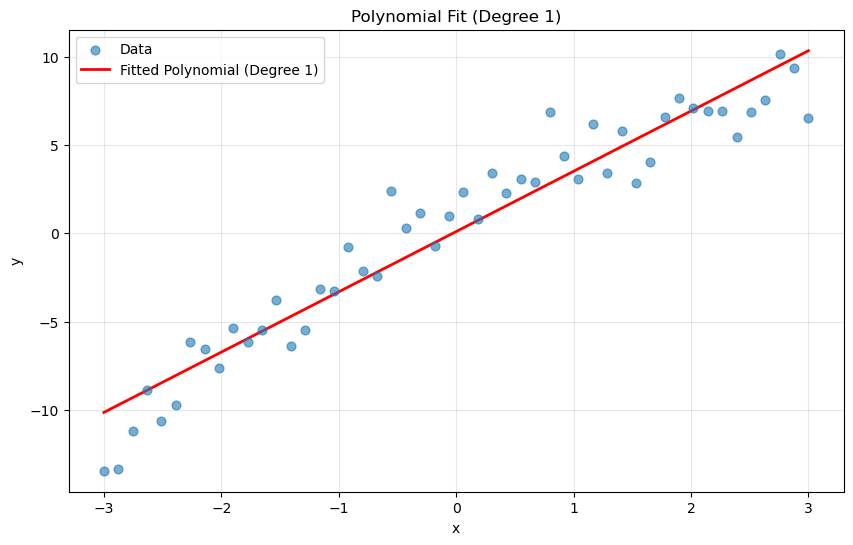

Linear fit coefficients: [0.10056465 3.41678244]
Polynomial: y = 0.101 + 3.417x



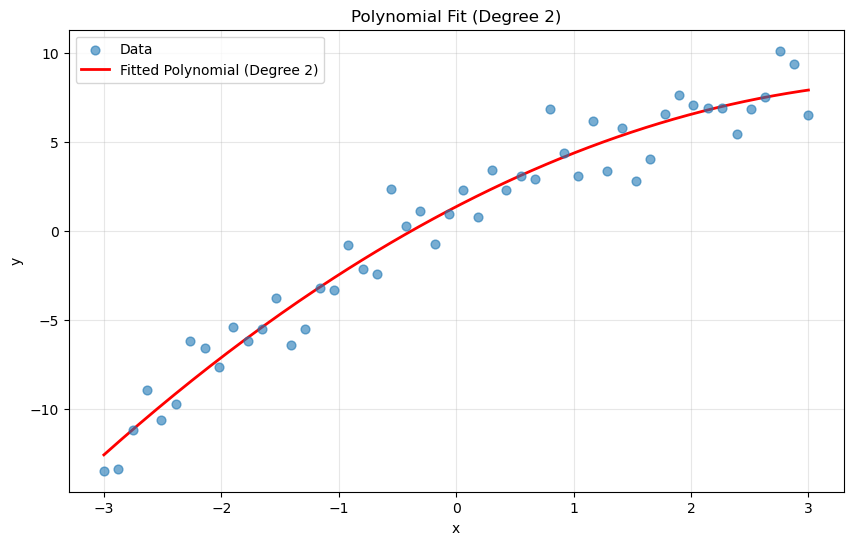

Quadratic fit coefficients: [ 1.3831668   3.41678244 -0.41076801]
Polynomial: y = 1.383 + 3.417x + -0.411x²



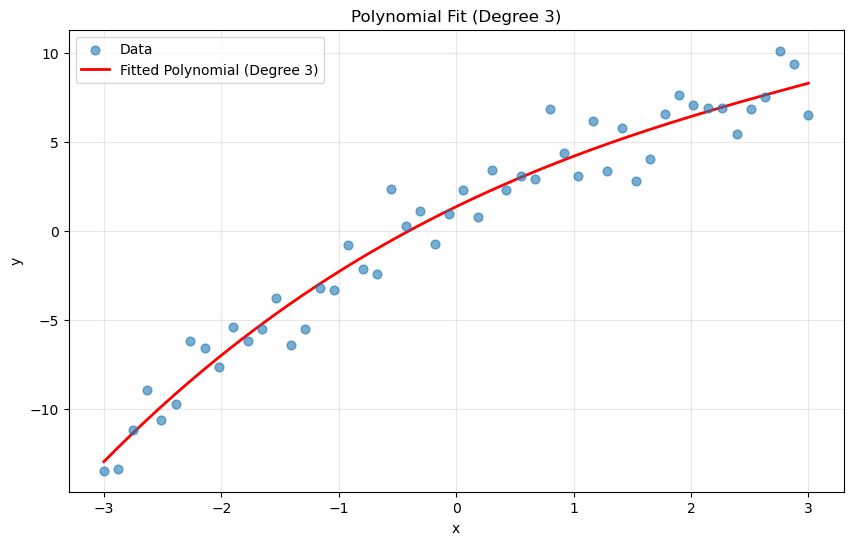

Cubic fit coefficients: [ 1.3831668   3.20508479 -0.41076801  0.03768599]
Polynomial: y = 1.383 + 3.205x + -0.411x² + 0.038x³

True polynomial: y = 2 + 3x - 0.5x² + 0.1x³


In [10]:
# Example: Fit polynomials of different degrees to the data
fig1, coef1 = fit_polynomial('polynomial_data.csv', N=1, show_plot=True)
print(f"Linear fit coefficients: {coef1}")
print(f"Polynomial: y = {coef1[0]:.3f} + {coef1[1]:.3f}x")
print()

fig2, coef2 = fit_polynomial('polynomial_data.csv', N=2, show_plot=True)
print(f"Quadratic fit coefficients: {coef2}")
print(f"Polynomial: y = {coef2[0]:.3f} + {coef2[1]:.3f}x + {coef2[2]:.3f}x²")
print()

fig3, coef3 = fit_polynomial('polynomial_data.csv', N=3, show_plot=True)
print(f"Cubic fit coefficients: {coef3}")
print(f"Polynomial: y = {coef3[0]:.3f} + {coef3[1]:.3f}x + {coef3[2]:.3f}x² + {coef3[3]:.3f}x³")
print("\nTrue polynomial: y = 2 + 3x - 0.5x² + 0.1x³")

In [ ]:
grader.check("q2")

## Required disclosure of use of AI technology

Please indicate whether you used AI to complete this homework. If you did, explain how you used it in the python cell below, as a comment.

In [17]:
# BEGIN SOLUTION NO PROMPT
# END SOLUTION
""" # BEGIN PROMPT
"""
# write ai disclosure here:

"""
"""; # END PROMPT

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit.

Upload the .zip file to Gradescope!

In [ ]:
grader.export(pdf=False, force_save=True, run_tests=True)